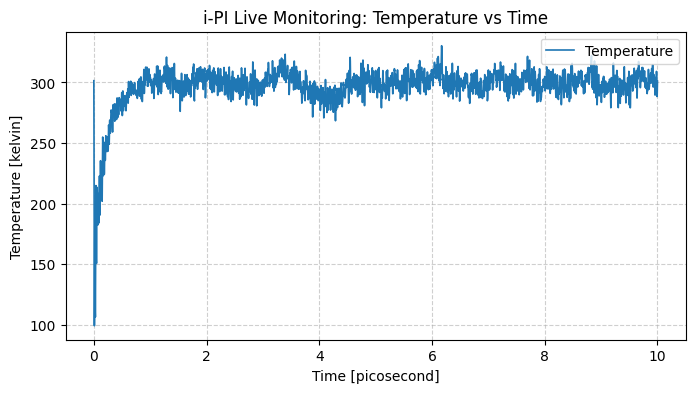

KeyboardInterrupt: 

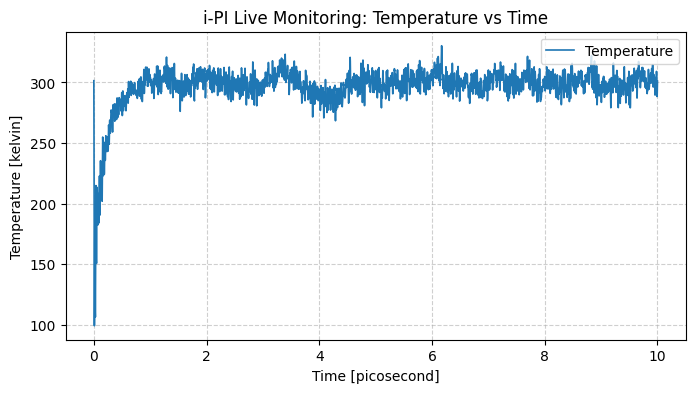

In [18]:
import re
import time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output


def parse_ipi_header(filepath):
    """Parses the i-PI header to map quantities to 0-based dataframe column indices."""
    col_map = {}
    pattern = re.compile(
        r"#\s+col(?:umn|s\.)\s+([\d\-]+)\s+-->\s+([^{\s]+)(?:\{([^}]+)\})?"
    )

    with open(filepath, "r") as f:
        for line in f:
            if not line.startswith("#"):
                break  # End of header

            match = pattern.search(line)
            if match:
                cols_str, variable, unit = match.groups()
                unit_str = f" [{unit}]" if unit else ""

                if "-" in cols_str:
                    start, end = map(int, cols_str.split("-"))
                    indices = list(range(start - 1, end))
                else:
                    indices = [int(cols_str) - 1]

                col_map[variable] = {"indices": indices, "unit": unit_str}
    return col_map


# Path to i-PI simulation.out file
logfile = "/scratch/project_465002371/zuxian/path_integral_MD/run_SiC_NPT/4H_SiC_110_rep2x4x7_T300K_beads1_steps20000_20260825_063005/simulation.out"

# Variables you want to monitor
X_VAR = "time"
Y_VAR = "temperature"

plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))

while True:
    try:
        col_map = parse_ipi_header(logfile)

        if X_VAR in col_map and Y_VAR in col_map:
            df = pd.read_csv(logfile, sep=r"\s+", comment="#", header=None)

            x_idx = col_map[X_VAR]["indices"][0]
            y_idx = col_map[Y_VAR]["indices"][0]

            ax.clear()
            ax.plot(
                df[x_idx],
                df[y_idx],
                label=f"{Y_VAR.capitalize()}",
                color="tab:blue",
                lw=1.2,
            )
            ax.set_xlabel(f"{X_VAR.capitalize()}{col_map[X_VAR]['unit']}")
            ax.set_ylabel(f"{Y_VAR.capitalize()}{col_map[Y_VAR]['unit']}")
            ax.grid(True, linestyle="--", alpha=0.6)
            ax.legend(loc="upper right")
            ax.set_title(
                f"i-PI Live Monitoring: {Y_VAR.capitalize()} vs {X_VAR.capitalize()}"
            )

            clear_output(wait=True)
            display(fig)
    except Exception as e:
        pass  # Handle file-lock or I/O race conditions during i-PI writes

    time.sleep(2)

KeyboardInterrupt: 

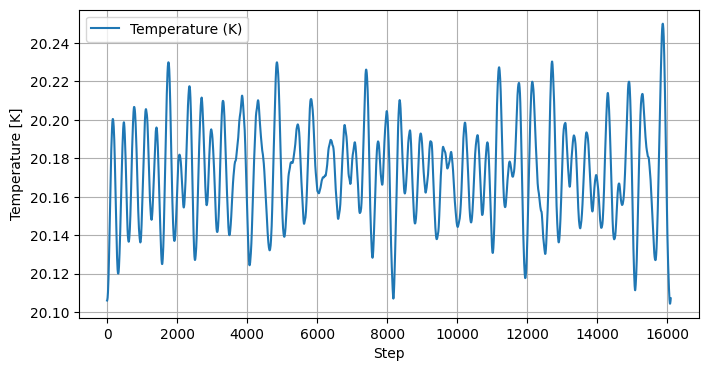

In [4]:
import time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import clear_output

# Path to i-PI simulation.out file
logfile = "/scratch/project_465002371/zuxian/path_integral_MD/run_SiC_NPT/4H_SiC_110_rep2x4x7_T300K_beads1_steps20000_20260825_063005/simulation.out"

plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))

while True:
    try:
        # i-PI simulation.out files typically start comment headers with '#'
        df = pd.read_csv(logfile, sep=r"\s+", comment="#", header=None)

        # Assuming step is column 0, total energy or temperature is column 1/2
        steps = df[0]
        temp = df[13]  # Adjust column index based on your i-PI output header

        ax.clear()
        ax.plot(steps, temp, label="Temperature (K)", color="tab:blue")
        ax.set_xlabel("Step")
        ax.set_ylabel("Temperature [K]")
        ax.grid(True)
        ax.legend()

        clear_output(wait=True)
        display(fig)
    except Exception as e:
        pass  # Handle brief file read locks during simulation write

    time.sleep(2)  # Update interval

In [16]:
import numpy as np

filename = "/scratch/project_465002371/zuxian/path_integral_MD/run_SiC_NPT/4H_SiC_110_rep2x4x7_T300K_beads1_steps20000_20260825_063005/simulation.out"


nx = 2
ny = 4
nz = 7

t_equil = 2.0  # ps

data = np.loadtxt(filename)

time = data[:, 1]

hxx = data[:, 13]   # column 14
hyy = data[:, 14]   # column 15
hzz = data[:, 15]   # column 16

hxy = data[:, 16]
hxz = data[:, 17]
hyz = data[:, 18]

volume = data[:, 19]

print(f"Simulation time range: {time.min():.3f} - {time.max():.3f} ps")

if t_equil >= time.max():
    raise ValueError(
        f"t_equil = {t_equil} ps is larger than the simulation length "
        f"({time.max():.3f} ps). Choose a smaller t_equil or run longer."
    )

mask = time >= t_equil

time_eq = time[mask]

hxx = hxx[mask]
hyy = hyy[mask]
hzz = hzz[mask]

hxy = hxy[mask]
hxz = hxz[mask]
hyz = hyz[mask]

volume = volume[mask]

# lattice constants
c = hxx / nx

a_y = hyy / (np.sqrt(3.0) * ny)
a_z = hzz / nz

a = 0.5 * (a_y + a_z)

print()
print("4H-SiC equilibrium lattice constants")
print("-------------------------------------")
print(
    f"Averaging interval: "
    f"{time_eq[0]:.3f} - {time_eq[-1]:.3f} ps"
)
print()

print(f"a from Y = {np.mean(a_y):.6f} Å")
print(f"a from Z = {np.mean(a_z):.6f} Å")
print(f"a mean   = {np.mean(a):.6f} Å")
print(f"c        = {np.mean(c):.6f} Å")

print()
print(f"std(a)   = {np.std(a):.6f} Å")
print(f"std(c)   = {np.std(c):.6f} Å")

print()
print(f"|a_Y-a_Z| = {abs(np.mean(a_y)-np.mean(a_z)):.6e} Å")
print(f"<V>       = {np.mean(volume):.6f} Å^3")

Simulation time range: 0.000 - 10.000 ps

4H-SiC equilibrium lattice constants
-------------------------------------
Averaging interval: 2.000 - 10.000 ps

a from Y = 3.083328 Å
a from Z = 3.083384 Å
a mean   = 3.083356 Å
c        = 10.086517 Å

std(a)   = 0.002970 Å
std(c)   = 0.014851 Å

|a_Y-a_Z| = 5.555925e-05 Å
<V>       = 62767.312239 Å^3


In [27]:
import numpy as np
import os

# ============================================================
# NPT output
# ============================================================

filename = (
    "/scratch/project_465002371/zuxian/path_integral_MD/"
    "run_SiC_NPT/"
    "4H_SiC_110_rep2x4x7_T1000K_beads1_steps20000_20260825_073446/"
    "simulation.out"
)

# Replication used in the NPT calculation
nx = 2
ny = 4
nz = 7

# Discard initial equilibration
t_equil = 2.0  # ps


# ============================================================
# Original 16-atom 4H-SiC orthogonal cell
# ============================================================

a_old = 3.073
c_old = 10.053

Lx_old = c_old
Ly_old = np.sqrt(3.0) * a_old
Lz_old = a_old


# atom type and coordinates
atoms = np.array([
    [1, 1, 0.000000000000, 0.000000000000, 0.000000000000],
    [2, 1, 0.000000000000, 2.661296065850, 1.536500000000],
    [3, 1, 5.026500000000, 0.000000000000, 0.000000000000],
    [4, 1, 5.026500000000, 2.661296065850, 1.536500000000],
    [5, 1, 2.513250000000, 1.774197377233, 0.000000000000],
    [6, 1, 2.513250000000, 4.435493443083, 1.536500000000],
    [7, 1, 7.539750000000, 3.548394754467, 0.000000000000],
    [8, 1, 7.539750000000, 0.887098688617, 1.536500000000],

    [9,  2, 1.884937500000, 0.000000000000, 0.000000000000],
    [10, 2, 1.884937500000, 2.661296065850, 1.536500000000],
    [11, 2, 6.911437500000, 0.000000000000, 0.000000000000],
    [12, 2, 6.911437500000, 2.661296065850, 1.536500000000],
    [13, 2, 4.398187500000, 1.774197377233, 0.000000000000],
    [14, 2, 4.398187500000, 4.435493443083, 1.536500000000],
    [15, 2, 9.424687500000, 3.548394754467, 0.000000000000],
    [16, 2, 9.424687500000, 0.887098688617, 1.536500000000],
], dtype=float)


# ============================================================
# Read NPT trajectory
# ============================================================

data = np.loadtxt(filename)

time = data[:, 1]

# i-PI columns 14-16
hxx = data[:, 13]
hyy = data[:, 14]
hzz = data[:, 15]

print(
    f"Simulation time range: "
    f"{time.min():.3f} - {time.max():.3f} ps"
)

if t_equil >= time.max():
    raise ValueError(
        f"t_equil = {t_equil} ps is larger than simulation length "
        f"{time.max():.3f} ps."
    )

mask = time >= t_equil

time_eq = time[mask]
hxx = hxx[mask]
hyy = hyy[mask]
hzz = hzz[mask]


# ============================================================
# Extract lattice constants
# ============================================================

# X = [0001]
c_t = hxx / nx

# Y = [1-100]
a_y_t = hyy / (np.sqrt(3.0) * ny)

# Z = [11-20]
a_z_t = hzz / nz


c_new = np.mean(c_t)

a_y = np.mean(a_y_t)
a_z = np.mean(a_z_t)

# Enforce hexagonal symmetry a = b
a_new = 0.5 * (a_y + a_z)
b_new = a_new


# ============================================================
# New orthogonal 16-atom cell
# ============================================================

Lx_new = c_new
Ly_new = np.sqrt(3.0) * a_new
Lz_new = a_new


# ============================================================
# Rescale atomic coordinates
#
# Equivalent to keeping fractional coordinates fixed.
# ============================================================

scale_x = Lx_new / Lx_old
scale_y = Ly_new / Ly_old
scale_z = Lz_new / Lz_old

atoms_new = atoms.copy()

atoms_new[:, 2] *= scale_x
atoms_new[:, 3] *= scale_y
atoms_new[:, 4] *= scale_z


# ============================================================
# Print result
# ============================================================

print()
print("==============================================")
print("4H-SiC NPT lattice constants")
print("==============================================")

print(
    f"Averaging interval : "
    f"{time_eq[0]:.3f} - {time_eq[-1]:.3f} ps"
)

print()
print(f"a from Y = {a_y:.9f} Å")
print(f"a from Z = {a_z:.9f} Å")

print()
print(f"a = {a_new:.9f} Å")
print(f"b = {b_new:.9f} Å")
print(f"c = {c_new:.9f} Å")

print()
print("Orthogonal 16-atom cell:")
print(f"Lx = c        = {Lx_new:.9f} Å")
print(f"Ly = sqrt(3)a = {Ly_new:.9f} Å")
print(f"Lz = a        = {Lz_new:.9f} Å")

print()
print(
    f"|a_Y - a_Z| = "
    f"{abs(a_y - a_z):.9e} Å"
)

print()
print("Thermal change relative to original structure:")
print(
    f"Δa/a = "
    f"{(a_new / a_old - 1.0) * 100:.6f} %"
)
print(
    f"Δc/c = "
    f"{(c_new / c_old - 1.0) * 100:.6f} %"
)


# ============================================================
# Write new LAMMPS data file
# ============================================================

output_dir = os.path.dirname(filename)

output_file = os.path.join(
    output_dir,
    "4H_SiC_110_NPT_1000K.lmp"
)

with open(output_file, "w") as f:

    f.write(
        "# 4H-SiC orthogonal cell: "
        "X=[0001], Y=[1-100], Z=[11-20] (beam along Z)\n"
    )

    f.write(
        f"# NPT equilibrated lattice constants: "
        f"a = b = {a_new:.9f} Angstrom, "
        f"c = {c_new:.9f} Angstrom\n"
    )

    f.write(
        f"# Averaged from {time_eq[0]:.3f} "
        f"to {time_eq[-1]:.3f} ps\n\n"
    )

    f.write("          16  atoms\n")
    f.write("           2  atom types\n\n")

    f.write(
        f"      0.000000000000      "
        f"{Lx_new:.12f}  xlo xhi\n"
    )

    f.write(
        f"      0.000000000000      "
        f"{Ly_new:.12f}  ylo yhi\n"
    )

    f.write(
        f"      0.000000000000      "
        f"{Lz_new:.12f}  zlo zhi\n"
    )

    f.write("\nMasses\n\n")

    f.write(
        "            1   28.08500000"
        "             # Si\n"
    )
    f.write(
        "            2   12.01100000"
        "             # C\n"
    )

    f.write("\nAtoms # atomic\n\n")

    for atom in atoms_new:

        atom_id = int(atom[0])
        atom_type = int(atom[1])

        x = atom[2]
        y = atom[3]
        z = atom[4]

        f.write(
            f"{atom_id:10d}"
            f"{atom_type:5d}"
            f"{x:22.12f}"
            f"{y:22.12f}"
            f"{z:22.12f}\n"
        )


print()
print("==============================================")
print("New LAMMPS structure written to:")
print(output_file)
print("==============================================")

Simulation time range: 0.000 - 10.000 ps

4H-SiC NPT lattice constants
Averaging interval : 2.000 - 10.000 ps

a from Y = 3.106681674 Å
a from Z = 3.106381185 Å

a = 3.106531430 Å
b = 3.106531430 Å
c = 10.159180592 Å

Orthogonal 16-atom cell:
Lx = c        = 10.159180592 Å
Ly = sqrt(3)a = 5.380670271 Å
Lz = a        = 3.106531430 Å

|a_Y - a_Z| = 3.004883237e-04 Å

Thermal change relative to original structure:
Δa/a = 1.091163 %
Δc/c = 1.056208 %

New LAMMPS structure written to:
/scratch/project_465002371/zuxian/path_integral_MD/run_SiC_NPT/4H_SiC_110_rep2x4x7_T1000K_beads1_steps20000_20260825_073446/4H_SiC_110_NPT_1000K.lmp
